In [8]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
%matplotlib inline 
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv(r"C:\Users\Hooshmand\Desktop\TCGA_InfoWithGrade.csv")
df.head(5)

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


array([[<Axes: title={'center': 'Grade'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Age_at_diagnosis'}>,
        <Axes: title={'center': 'Race'}>,
        <Axes: title={'center': 'IDH1'}>],
       [<Axes: title={'center': 'TP53'}>,
        <Axes: title={'center': 'ATRX'}>,
        <Axes: title={'center': 'PTEN'}>,
        <Axes: title={'center': 'EGFR'}>,
        <Axes: title={'center': 'CIC'}>],
       [<Axes: title={'center': 'MUC16'}>,
        <Axes: title={'center': 'PIK3CA'}>,
        <Axes: title={'center': 'NF1'}>,
        <Axes: title={'center': 'PIK3R1'}>,
        <Axes: title={'center': 'FUBP1'}>],
       [<Axes: title={'center': 'RB1'}>,
        <Axes: title={'center': 'NOTCH1'}>,
        <Axes: title={'center': 'BCOR'}>,
        <Axes: title={'center': 'CSMD3'}>,
        <Axes: title={'center': 'SMARCA4'}>],
       [<Axes: title={'center': 'GRIN2A'}>,
        <Axes: title={'center': 'IDH2'}>,
        <Axes: title={'center': 'FAT4'}>,
    

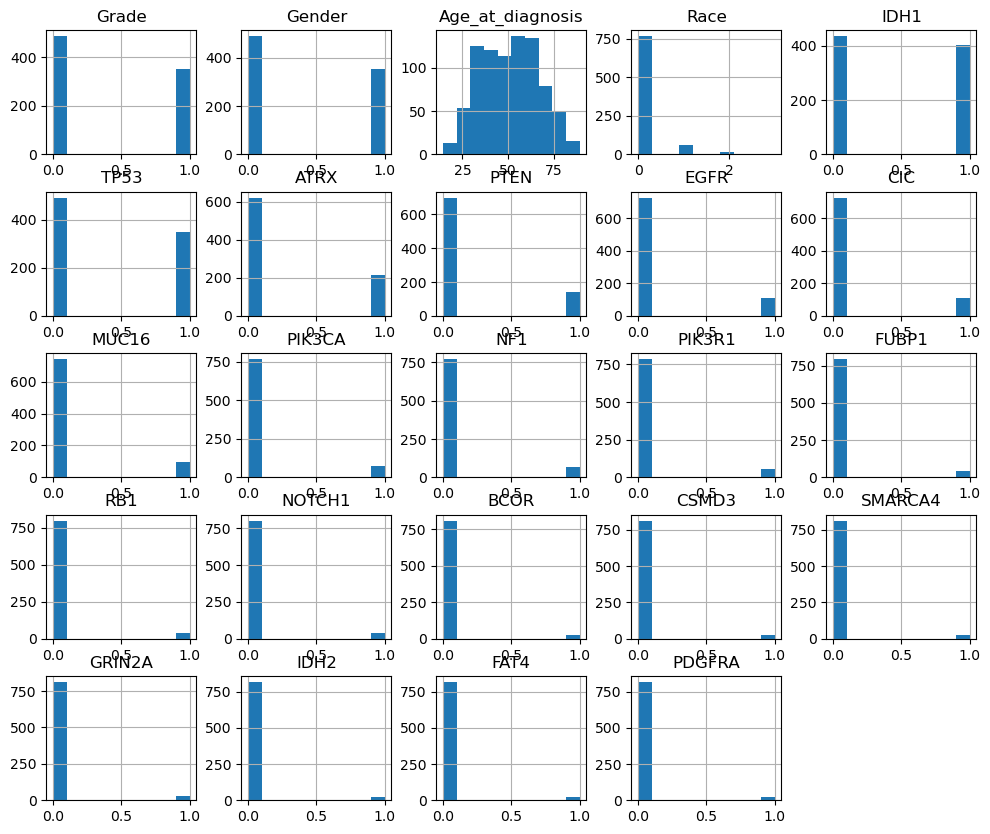

In [10]:
df.hist(figsize=(12,10))

In [11]:
df['Grade'].value_counts()

Grade
0    487
1    352
Name: count, dtype: int64

In [12]:
corr = df.corr(numeric_only=True)

print(corr['Grade'].sort_values(ascending=False))

Grade               1.000000
Age_at_diagnosis    0.529203
PTEN                0.367174
EGFR                0.241527
RB1                 0.195168
MUC16               0.119447
GRIN2A              0.118685
PDGFRA              0.102327
PIK3R1              0.101813
NF1                 0.088123
Race                0.080084
CSMD3               0.050257
FAT4                0.034767
PIK3CA              0.028905
BCOR               -0.002206
Gender             -0.060033
SMARCA4            -0.100286
IDH2               -0.113150
TP53               -0.161786
FUBP1              -0.180956
NOTCH1             -0.185175
CIC                -0.303459
ATRX               -0.314625
IDH1               -0.708141
Name: Grade, dtype: float64


In [13]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Grade', axis=1)
y = df['Grade']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importance = rf.feature_importances_

for col, imp in sorted(zip(X.columns, importance),key=lambda x: x[1],reverse=True):
    print(col, imp)

Age_at_diagnosis 0.33454724723326856
IDH1 0.2780560682740684
CIC 0.04535952820806699
PTEN 0.04513401285012449
ATRX 0.0429844355775338
EGFR 0.029020979792716558
Race 0.027488790559592885
IDH2 0.02671217404986453
TP53 0.024161133707355297
Gender 0.02193344136146207
PIK3CA 0.014956868516599752
NF1 0.014872585269347814
RB1 0.013585637502834732
MUC16 0.013484065349206325
NOTCH1 0.01241677156094084
PIK3R1 0.011211636411216646
FUBP1 0.010103641498534264
PDGFRA 0.007266612362586936
GRIN2A 0.006582547150527744
FAT4 0.006451944533426901
BCOR 0.006051128315094114
CSMD3 0.004257930513042432
SMARCA4 0.003360819402587928


In [33]:
X = df[['Age_at_diagnosis','IDH1','TP53','ATRX','CIC']]
y = df['Grade'].astype(int)

X = X.values
y = y.values

In [37]:
from sklearn import preprocessing
X = preprocessing.StandardScaler().fit(X).transform(X)
X[0:5]

array([[ 0.02323261,  1.0376573 , -0.84187745, -0.59065607, -0.39047731],
       [-0.77839981,  1.0376573 , -0.84187745, -0.59065607,  2.56096829],
       [-1.00461564,  1.0376573 ,  1.18782134,  1.69303262, -0.39047731],
       [-1.15691305,  1.0376573 ,  1.18782134,  1.69303262, -0.39047731],
       [-1.23784097,  1.0376573 ,  1.18782134,  1.69303262, -0.39047731]])

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (671, 5) (671,)
Test set: (168, 5) (168,)


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
LR = LogisticRegression(C=0.01, solver='liblinear').fit(X_train,y_train)
LR

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [40]:
yhat = LR.predict(X_test)
yhat

array([1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [41]:
yhat_prob = LR.predict_proba(X_test)
yhat_prob

array([[0.4542265 , 0.5457735 ],
       [0.2970555 , 0.7029445 ],
       [0.17014776, 0.82985224],
       [0.39029774, 0.60970226],
       [0.7382615 , 0.2617385 ],
       [0.21272672, 0.78727328],
       [0.83469619, 0.16530381],
       [0.65734054, 0.34265946],
       [0.83073065, 0.16926935],
       [0.30772375, 0.69227625],
       [0.8097565 , 0.1902435 ],
       [0.60572096, 0.39427904],
       [0.29317823, 0.70682177],
       [0.15900353, 0.84099647],
       [0.81783655, 0.18216345],
       [0.85664807, 0.14335193],
       [0.22156231, 0.77843769],
       [0.44545198, 0.55454802],
       [0.29995565, 0.70004435],
       [0.8516426 , 0.1483574 ],
       [0.23514816, 0.76485184],
       [0.84727989, 0.15272011],
       [0.19247589, 0.80752411],
       [0.77419768, 0.22580232],
       [0.26182416, 0.73817584],
       [0.76401594, 0.23598406],
       [0.27266628, 0.72733372],
       [0.8156802 , 0.1843198 ],
       [0.49100178, 0.50899822],
       [0.72697325, 0.27302675],
       [0.

In [42]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, yhat,pos_label=0)

0.8155339805825242

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,normalize=False,title='Confusion matrix',cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(y_test, yhat, labels=[1,0]))

[[65  8]
 [11 84]]


Confusion matrix, without normalization
[[65  8]
 [11 84]]


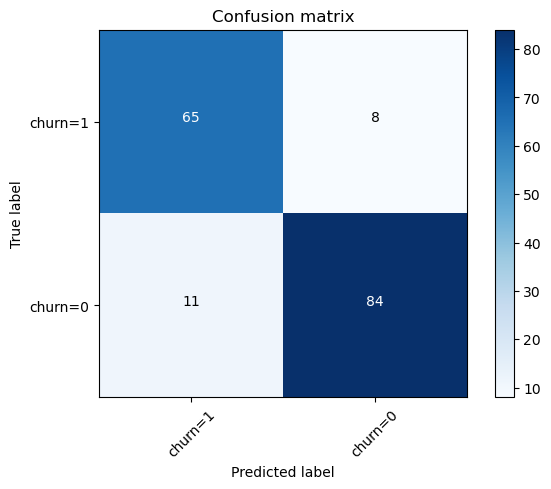

In [44]:


# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, yhat, labels=[1,0])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['churn=1','churn=0'],normalize= False,  title='Confusion matrix')